# Notebook Introduction

Consider the Lotka-Volterra equations for a predator-prey dynamics:

$$
\begin{align}
& \dot x = \alpha x - \gamma xy \\
& \dot y = -\beta y + \eta (\gamma xy)
\end{align}
$$

Suppose we only know $\alpha, \beta$ and $\eta$, how can we approximate the term $\gamma xy$? In this case we will use and implement the *Universal Differential Equations* according to [1] in Python.

In particular, we will:
1. Generate a synthetic dataset by fixing the parameters first
2. Consider the L-V equations only with $\alpha, \beta, \eta$ known; the term $\gamma xy$ will be approximated with a Neural Network defined as $\texttt{NN}(\theta, t)$
3. Train the Neural Network with the method described in the paper, in particular using numerical integration of ODEs (Newton's first-order method) 

The loss used to train the NN will be the MSE loss, defined as 

$$
\mathcal L_{\texttt{MSE} }(\theta) := \frac{1}{N} \sum_{i = 1, \ldots, n} [(\hat x_\theta(t_i) - x_i)^2 + (\hat y_\theta(t_i) - y_i)^2]
$$

Where $\hat x_\theta, \hat y_\theta$ are the solutions of the following parametrised DE in a certain time interval $[0, T]$:

$$
\begin{align}
& \dot x = \alpha x - \texttt{NN}(\theta, t)[1] \\
& \dot y = -\beta y + \cdot \texttt{NN}(\theta, t)[0]
\end{align}
$$


> *Remark.* Our approach will differ from [1] as we will approximate the term $\gamma xy$ with *only one* neural network, instead of two. We consider this approach to be better and leverage our knowledge of the system further.

Moreover the neural network will have two inputs and two outputs, one for each component of the dynamical system.

**In this alternative version, we will consider the anti-dimensionalised version of the Lotka-Volterra dynamics defined as follows:**

$$
\begin{align}
& \dot x = x(1-y) \\
& \dot y = cy(x-1)
\end{align}
$$

And thus we will have the following UDE proposed:

$$
\begin{align}
& \dot x = x-NN(x,y)[0] \\
& \dot y = c(NN(x,y)[1] - y)
\end{align}
$$


And we will see how results vary by setting $c<0$ and $c>0$


In the end, we will compare the results with the ones presented in the paper.

In [1]:
# Libraries
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from torch import nn, optim 
import torch
from torchdiffeq import odeint
import pysindy as ps

if torch.cuda.is_available():
    device = "cuda:0"

else:
    device ="cpu"

device="cpu"

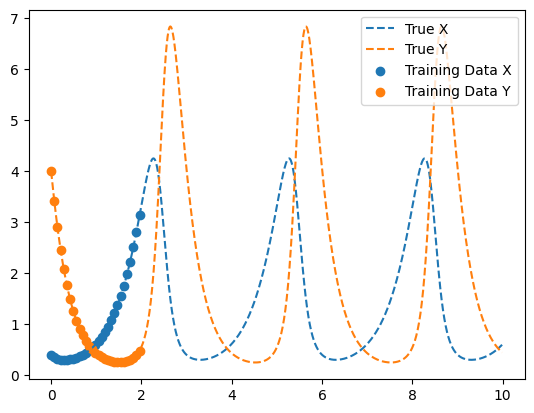

In [5]:
# Part 1: Synthetic Data Generation
c = 2

def lotka_volterra(t, data, c):
    x = data[0]
    y = data[1]
    return np.array([2*x - x*y, 
                    -3*y + c*x*y])

x0 = (0.4, 4)

sol = solve_ivp(lotka_volterra, t_span = [0, 10], t_eval=np.arange(0, 10, 0.01), args=(c,), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

plt.plot(T, X, "--", label="True X")
plt.plot(T, Y, "--", label="True Y")

T_train = T[:200:7]
X_train = X[:200:7]
Y_train = Y[:200:7]

plt.scatter(T_train, X_train, label="Training Data X")
plt.scatter(T_train, Y_train, label="Training Data Y")

plt.legend()

plt.show()




In [6]:
# Define UDE

class universal_LV(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.a = a 
        self.b = b

        self.scale_net = torch.tensor([-1., 1], device=device)
        self.scale_dynamics = torch.tensor([a, -b], dtype=torch.float32, device=device)

        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.SiLU(),
            nn.Linear(16, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 16), 
            nn.SiLU(),
            nn.Linear(16, 2),
            nn.Linear(2,1),
            nn.Linear(1,2)
        ) 


    def forward(self, t, data):
        out_net = self.net(data)
        out_net *= self.scale_net

        summ = data * self.scale_dynamics
        return out_net + summ
    
class neural_LV(nn.Module):
    # other case: full NN approach
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.SiLU(),
            nn.Linear(16, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 16), 
            nn.SiLU(),
            nn.Linear(16, 2)
        ) 

    def forward(self, t, data):
        return self.net(data)


In [22]:
# Train UDE network to training data

from tqdm import tqdm 
my_lv = universal_LV(2, 3)
my_lv = my_lv.to(device)


lr = 0.03
optimizer = torch.optim.Adam(my_lv.net.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1, 1500)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1: MSE Loss (L2 norm)= 4.960E+01
Epoch 2: MSE Loss (L2 norm)= 4.154E+01
Epoch 3: MSE Loss (L2 norm)= 3.237E+01
Epoch 4: MSE Loss (L2 norm)= 2.055E+01
Epoch 5: MSE Loss (L2 norm)= 3.362E+00
Epoch 6: MSE Loss (L2 norm)= 1.573E+01
Epoch 7: MSE Loss (L2 norm)= 4.426E+00
Epoch 8: MSE Loss (L2 norm)= 2.286E-01
Epoch 9: MSE Loss (L2 norm)= 1.122E+00
Epoch 10: MSE Loss (L2 norm)= 2.813E+00
Epoch 11: MSE Loss (L2 norm)= 3.052E+00
Epoch 12: MSE Loss (L2 norm)= 2.219E+00
Epoch 13: MSE Loss (L2 norm)= 1.023E+00
Epoch 14: MSE Loss (L2 norm)= 1.579E-01
Epoch 15: MSE Loss (L2 norm)= 1.194E-01
Epoch 16: MSE Loss (L2 norm)= 7.193E-01
Epoch 17: MSE Loss (L2 norm)= 8.235E-01
Epoch 18: MSE Loss (L2 norm)= 8.157E-01
Epoch 19: MSE Loss (L2 norm)= 8.010E-01
Epoch 20: MSE Loss (L2 norm)= 7.837E-01
Epoch 21: MSE Loss (L2 norm)= 7.651E-01
Epoch 22: MSE Loss (L2 norm)= 7.456E-01
Epoch 23: MSE Loss (L2 norm)= 7.254E-01
Epoch 24: MSE Loss (L2 norm)= 7.049E-01
Epoch 25: MSE Loss (L2 norm)= 6.840E-01
Epoch 26:

In [23]:
lr = 0.005
optimizer = torch.optim.Adam(my_lv.net.parameters(), lr)

for EPOCH in (range(1500, 2000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1500: MSE Loss (L2 norm)= 1.896E-04
Epoch 1501: MSE Loss (L2 norm)= 3.633E-01
Epoch 1502: MSE Loss (L2 norm)= 2.332E-02
Epoch 1503: MSE Loss (L2 norm)= 1.129E-01
Epoch 1504: MSE Loss (L2 norm)= 1.090E+00
Epoch 1505: MSE Loss (L2 norm)= 1.161E-01
Epoch 1506: MSE Loss (L2 norm)= 1.856E-02
Epoch 1507: MSE Loss (L2 norm)= 4.656E-03
Epoch 1508: MSE Loss (L2 norm)= 5.155E-02
Epoch 1509: MSE Loss (L2 norm)= 1.197E-01
Epoch 1510: MSE Loss (L2 norm)= 1.779E-01
Epoch 1511: MSE Loss (L2 norm)= 2.078E-01
Epoch 1512: MSE Loss (L2 norm)= 2.040E-01
Epoch 1513: MSE Loss (L2 norm)= 1.716E-01
Epoch 1514: MSE Loss (L2 norm)= 1.225E-01
Epoch 1515: MSE Loss (L2 norm)= 7.064E-02
Epoch 1516: MSE Loss (L2 norm)= 2.880E-02
Epoch 1517: MSE Loss (L2 norm)= 5.336E-03
Epoch 1518: MSE Loss (L2 norm)= 2.489E-03
Epoch 1519: MSE Loss (L2 norm)= 1.620E-02
Epoch 1520: MSE Loss (L2 norm)= 3.786E-02
Epoch 1521: MSE Loss (L2 norm)= 5.756E-02
Epoch 1522: MSE Loss (L2 norm)= 6.769E-02
Epoch 1523: MSE Loss (L2 norm)= 6.

In [24]:
for EPOCH in (range(2000, 2500)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 2000: MSE Loss (L2 norm)= 2.288E-04
Epoch 2001: MSE Loss (L2 norm)= 2.278E-04
Epoch 2002: MSE Loss (L2 norm)= 2.267E-04
Epoch 2003: MSE Loss (L2 norm)= 2.257E-04
Epoch 2004: MSE Loss (L2 norm)= 2.247E-04
Epoch 2005: MSE Loss (L2 norm)= 2.237E-04
Epoch 2006: MSE Loss (L2 norm)= 2.227E-04
Epoch 2007: MSE Loss (L2 norm)= 2.217E-04
Epoch 2008: MSE Loss (L2 norm)= 2.207E-04
Epoch 2009: MSE Loss (L2 norm)= 2.197E-04
Epoch 2010: MSE Loss (L2 norm)= 2.187E-04
Epoch 2011: MSE Loss (L2 norm)= 2.177E-04
Epoch 2012: MSE Loss (L2 norm)= 2.168E-04
Epoch 2013: MSE Loss (L2 norm)= 2.158E-04
Epoch 2014: MSE Loss (L2 norm)= 2.149E-04
Epoch 2015: MSE Loss (L2 norm)= 2.139E-04
Epoch 2016: MSE Loss (L2 norm)= 2.130E-04
Epoch 2017: MSE Loss (L2 norm)= 2.120E-04
Epoch 2018: MSE Loss (L2 norm)= 2.111E-04
Epoch 2019: MSE Loss (L2 norm)= 2.102E-04
Epoch 2020: MSE Loss (L2 norm)= 2.093E-04
Epoch 2021: MSE Loss (L2 norm)= 2.084E-04
Epoch 2022: MSE Loss (L2 norm)= 2.074E-04
Epoch 2023: MSE Loss (L2 norm)= 2.

In [25]:
for EPOCH in (range(2500, 3500)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 2500: MSE Loss (L2 norm)= 9.817E-05
Epoch 2501: MSE Loss (L2 norm)= 9.810E-05
Epoch 2502: MSE Loss (L2 norm)= 9.803E-05
Epoch 2503: MSE Loss (L2 norm)= 9.796E-05
Epoch 2504: MSE Loss (L2 norm)= 9.789E-05
Epoch 2505: MSE Loss (L2 norm)= 9.782E-05
Epoch 2506: MSE Loss (L2 norm)= 9.778E-05
Epoch 2507: MSE Loss (L2 norm)= 9.769E-05
Epoch 2508: MSE Loss (L2 norm)= 9.762E-05
Epoch 2509: MSE Loss (L2 norm)= 9.755E-05
Epoch 2510: MSE Loss (L2 norm)= 9.748E-05
Epoch 2511: MSE Loss (L2 norm)= 9.741E-05
Epoch 2512: MSE Loss (L2 norm)= 9.734E-05
Epoch 2513: MSE Loss (L2 norm)= 9.728E-05
Epoch 2514: MSE Loss (L2 norm)= 9.721E-05
Epoch 2515: MSE Loss (L2 norm)= 9.713E-05
Epoch 2516: MSE Loss (L2 norm)= 9.706E-05
Epoch 2517: MSE Loss (L2 norm)= 9.700E-05
Epoch 2518: MSE Loss (L2 norm)= 9.693E-05
Epoch 2519: MSE Loss (L2 norm)= 9.687E-05
Epoch 2520: MSE Loss (L2 norm)= 9.688E-05
Epoch 2521: MSE Loss (L2 norm)= 9.672E-05
Epoch 2522: MSE Loss (L2 norm)= 9.666E-05
Epoch 2523: MSE Loss (L2 norm)= 9.

In [11]:
# Train neural ODE network to training data
my_neural_lv = neural_LV()
my_neural_lv = my_neural_lv.to(device)

from tqdm import tqdm 

lr = 0.01
n_optimizer = torch.optim.Adam(my_neural_lv.net.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1, 1500)):
    n_optimizer.zero_grad()

    # get forward solution
    info = odeint(my_neural_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    n_optimizer.step()

    with torch.no_grad():
        
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1: MSE Loss (L2 norm)= 5.640E+00
Epoch 2: MSE Loss (L2 norm)= 5.420E+00
Epoch 3: MSE Loss (L2 norm)= 5.189E+00
Epoch 4: MSE Loss (L2 norm)= 4.902E+00
Epoch 5: MSE Loss (L2 norm)= 4.509E+00
Epoch 6: MSE Loss (L2 norm)= 3.946E+00
Epoch 7: MSE Loss (L2 norm)= 3.160E+00
Epoch 8: MSE Loss (L2 norm)= 2.159E+00
Epoch 9: MSE Loss (L2 norm)= 1.120E+00
Epoch 10: MSE Loss (L2 norm)= 6.216E-01
Epoch 11: MSE Loss (L2 norm)= 1.117E+00
Epoch 12: MSE Loss (L2 norm)= 1.048E+00
Epoch 13: MSE Loss (L2 norm)= 7.415E-01
Epoch 14: MSE Loss (L2 norm)= 5.702E-01
Epoch 15: MSE Loss (L2 norm)= 5.547E-01
Epoch 16: MSE Loss (L2 norm)= 6.065E-01
Epoch 17: MSE Loss (L2 norm)= 6.487E-01
Epoch 18: MSE Loss (L2 norm)= 6.469E-01
Epoch 19: MSE Loss (L2 norm)= 6.006E-01
Epoch 20: MSE Loss (L2 norm)= 5.264E-01
Epoch 21: MSE Loss (L2 norm)= 4.449E-01
Epoch 22: MSE Loss (L2 norm)= 3.727E-01
Epoch 23: MSE Loss (L2 norm)= 3.194E-01
Epoch 24: MSE Loss (L2 norm)= 2.876E-01
Epoch 25: MSE Loss (L2 norm)= 2.745E-01
Epoch 26:

In [43]:
lr = 0.005
n_optimizer = torch.optim.Adam(my_neural_lv.net.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32).to(device)
T_train_torch = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)

for EPOCH in (range(1500, 3500)):
    n_optimizer.zero_grad()

    # get forward solution
    info = odeint(my_neural_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - torch.stack([X_train_torch, Y_train_torch], dim=1)) ** 2)
    loss_norm.backward()

    n_optimizer.step()

    with torch.no_grad():
        
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")
        pass


Epoch 1500: MSE Loss (L2 norm)= 5.678E-04
Epoch 1501: MSE Loss (L2 norm)= 1.266E-01
Epoch 1502: MSE Loss (L2 norm)= 1.750E-02
Epoch 1503: MSE Loss (L2 norm)= 4.760E-02
Epoch 1504: MSE Loss (L2 norm)= 3.891E-02
Epoch 1505: MSE Loss (L2 norm)= 5.075E-03
Epoch 1506: MSE Loss (L2 norm)= 8.206E-03
Epoch 1507: MSE Loss (L2 norm)= 2.229E-02
Epoch 1508: MSE Loss (L2 norm)= 2.844E-02
Epoch 1509: MSE Loss (L2 norm)= 2.419E-02
Epoch 1510: MSE Loss (L2 norm)= 1.492E-02
Epoch 1511: MSE Loss (L2 norm)= 8.061E-03
Epoch 1512: MSE Loss (L2 norm)= 8.532E-03
Epoch 1513: MSE Loss (L2 norm)= 1.434E-02
Epoch 1514: MSE Loss (L2 norm)= 1.737E-02
Epoch 1515: MSE Loss (L2 norm)= 1.322E-02
Epoch 1516: MSE Loss (L2 norm)= 6.622E-03
Epoch 1517: MSE Loss (L2 norm)= 3.771E-03
Epoch 1518: MSE Loss (L2 norm)= 5.425E-03
Epoch 1519: MSE Loss (L2 norm)= 8.005E-03
Epoch 1520: MSE Loss (L2 norm)= 7.992E-03
Epoch 1521: MSE Loss (L2 norm)= 4.893E-03
Epoch 1522: MSE Loss (L2 norm)= 1.454E-03
Epoch 1523: MSE Loss (L2 norm)= 1.

In [44]:
pred = odeint(my_lv, x0_torch, T_train_torch, method='dopri5', atol=1e-5, rtol=1e-5)
pred_neural = odeint(my_neural_lv, x0_torch, T_train_torch)

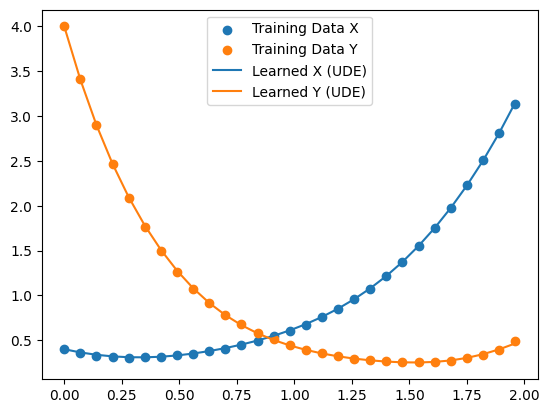

In [45]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred[:, 0].cpu().detach().numpy(), label="Learned X (UDE)")
plt.plot(T_train, pred[:, 1].cpu().detach().numpy(), label="Learned Y (UDE)")

plt.legend()

plt.show()


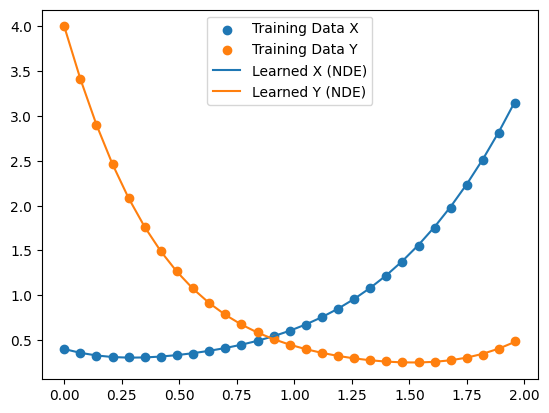

In [46]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred_neural[:, 0].cpu().detach().numpy(), label="Learned X (NDE)")
plt.plot(T_train, pred_neural[:, 1].cpu().detach().numpy(), label="Learned Y (NDE)")

plt.legend()

plt.show()


In [47]:
# Train SINDy with the known derivatives now!
# UDEs

pred_new = odeint(my_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 2, 0.01))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ(0.22)
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.998 x + -0.942 x y
(y)' = -2.939 y +  1.801 x y


In [55]:
# do the same thing with NDE
pred_new = odeint(my_neural_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 3, 0.001))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.646 x + -0.295 y
(y)' =  0.297 x + -2.206 y +  0.173 x^2 + -0.467 x y


In [51]:
# What if we trained SINDy without UDE-enhanched derivatives

sol = solve_ivp(lotka_volterra, t_span = [0, 20], t_eval=np.arange(0, 20, 0.01), args= (1.25,), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

T_train_ps = T[:200:7]
X_train_ps = X[:200:7]
Y_train_ps = Y[:200:7]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ(0.2)
)

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    # x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

# Even by manipulating the STLSQ coefficient we won't be able to get rid of the quadratic and cubic term of the unneccessary coefficients

(x)' =  2.002 x + -0.997 x y
(y)' = -3.007 y +  1.256 x y


In [22]:
# plotl earned dynamics

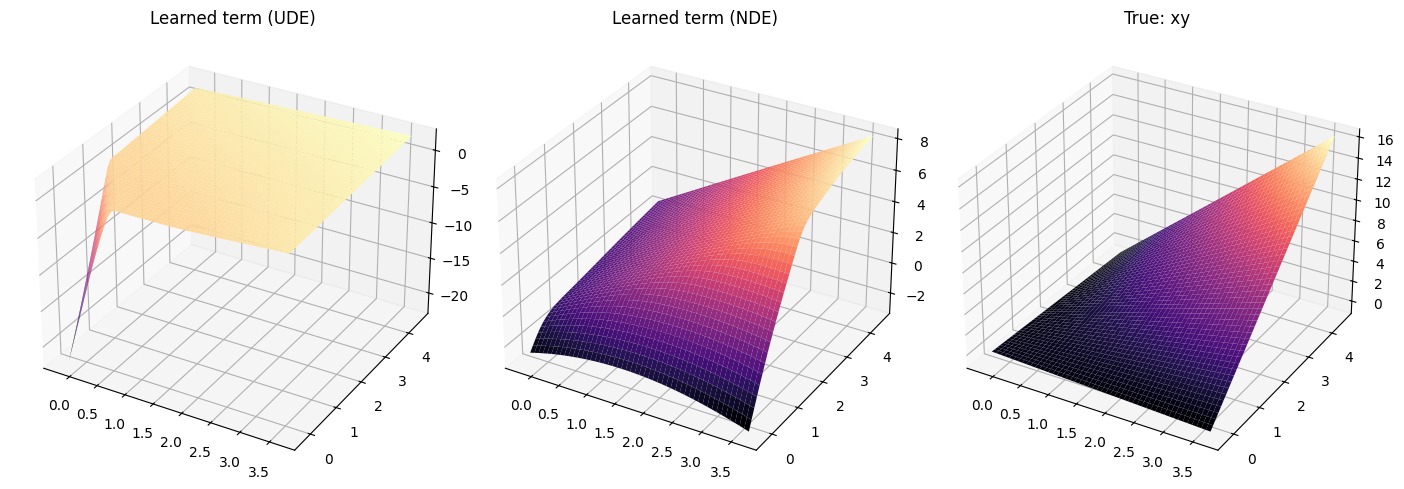

In [56]:
x_min, x_max = X_train.min() - 0.5, X_train.max() + 0.5
y_min, y_max = Y_train.min() - 0.5, Y_train.max() + 0.5

x = np.linspace(x_min, x_max, 50)
y = np.linspace(y_min, y_max, 50)
X, Y = np.meshgrid(x, y)

# Feed grid through NN
punti_input = np.stack([X.ravel(), Y.ravel()], axis=-1)
input_tensor = torch.tensor(punti_input, dtype=torch.float32)

with torch.no_grad():
    z_pred = my_lv.net(input_tensor)[:, 0]  # Take first output
    Z_nn = z_pred.reshape(X.shape).numpy()
    z_ude_pred = my_neural_lv(0, input_tensor)[:, 0]
    Z_ude_nn = - z_ude_pred.reshape(X.shape).numpy() + 2 * X # transformation into what should be the beta * x * y term

# True function: xy
Z_true = X * Y

fig = plt.figure(figsize=(14, 5))

# Plot UDE
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z_nn, cmap='magma', edgecolor='none')
ax1.set_title('Learned term (UDE)')

# Plot NDE 
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, Z_ude_nn, cmap='magma', edgecolor='none')
ax2.set_title('Learned term (NDE)')

# Plot NDE 
ax2 = fig.add_subplot(133, projection='3d')
ax2.plot_surface(X, Y, Z_true, cmap='magma', edgecolor='none')
ax2.set_title('True: xy')


plt.tight_layout()
plt.show()

In [57]:
torch.save(my_lv.state_dict(), "my_lv_ude_weights_alt2.dinomeng")
torch.save(my_neural_lv.state_dict(), "my_lv_nde_weights_alt2.dinomeng")


# References

[1] C. Rackauckas et al., ‘Universal Differential Equations for Scientific Machine Learning’, Aug. 31, 2020, In Review. doi: 10.21203/rs.3.rs-55125/v1.
